<a href="https://colab.research.google.com/github/andreagrioni/train/blob/master/00_SAM_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You will learn to open a SAM file, and extract different metrics. You first 

need to initialize the directory, and download files from github.

You can interact with the Command Line Interface by typing '!' before the 

command you want to execute.

In [60]:
# clean-up old train' folder
! rm -rf './train/'
# copy public 'train' repository from github
! git clone https://github.com/andreagrioni/train.git

Cloning into 'train'...
remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 23 (delta 10), reused 0 (delta 0), pack-reused 0
Unpacking objects: 100% (23/23), done.


we import external Python modules by using 'import'.

os = provides several methods to interact with the operative system

collections = handly extention of pre-built Python data structures

numpy = we need array data structure

In [0]:
import os
import collections
import numpy as np

Each line of the SAM file is an alignemnt, which is defined by several metrics.

You can read more about SAM file at:

https://samtools.github.io/hts-specs/SAMv1.pdf.

For now, we will write a function that takes as arguments a single line of the

SAM file and a list of positional index we want to retrive from each line.

In [0]:
def get_metrics(line, indexes = None):
  '''
  return a numpy array data structure
  storing values from the indexes list. 
  
  arguments:
  line = line from the SAM file
  indexes = list on positional indexes
  '''
  # remove new line characters from
  # start and end of the string with
  # str.strip() method;
  # break string at tab '\t' with 
  # the str.split('\t') method.
  column = line.strip().split('\t')
  # convert column to array
  selection = np.array(column)
  # retrive indexes and return
  # output.
  if indexes == None:
    return selection
  return selection[indexes]

In [0]:
# load SAM file
tfile = open('train/train.sam')

we will retrive read ids and chromosome, which corresponds to column 1 and 3 of 

the SAM file. Column 1 and 3 of SAM file are positional index 0 and 2.

We will combine the built-in function map() and lambda to optimize 

the process. map() returns an iterator that yield your values. Yield

is a keyword similar to return, but the values is generated

on the fly (generator). It reduce the memory usage. 

In [0]:
targets = [0, 2]

alignments = map(
    lambda x: get_metrics(x,
                          targets
                          ),
    tfile
    )

A for loop will be used to generate each value inside the map iterator. We will

store each value into a defaultdict from the collections module. defaultdict()

is a dictionary where you can define a default key value.

**You can loop over a map() generator only once**.

In [0]:
tot_alignments = collections.defaultdict(list)

for element in alignments:
  read_id, chromosome = element
  tot_alignments[chromosome].append(read_id)

We visualize the number of alignments for each chromosome

through the Python matplotlib library.

We need to import the module.

In [0]:
import matplotlib.pyplot as plt

# %matplotlib is a Python magic 
# function that sets the 
# backend of matplotlib to the 
# 'inline' backend. In this way,
# each plot will be rendered in
# the notebook.
%matplotlib inline

We use the bar() function from matplotlib to visualize our plot. we need two 

arguments for the function. bar() arguments are a scalar and the height for the 

corresponding scalar. we will create three lists, which are ordered data

structure.

In [0]:
# store chromosome names
chrom_names = list()
# store number of alignments
chrom_alignments = list()
# store an arbitrary scalar for each 
# chromosome.
x_scalar = list()

# loop over all alignments and update lists.
for number, values in enumerate(tot_alignments.items()):
  chromosome, alignments = values
  x_scalar.append(number)
  chrom_names.append(chromosome)
  chrom_alignments.append(len(alignments))


we can now define the bar plot and visualize it.

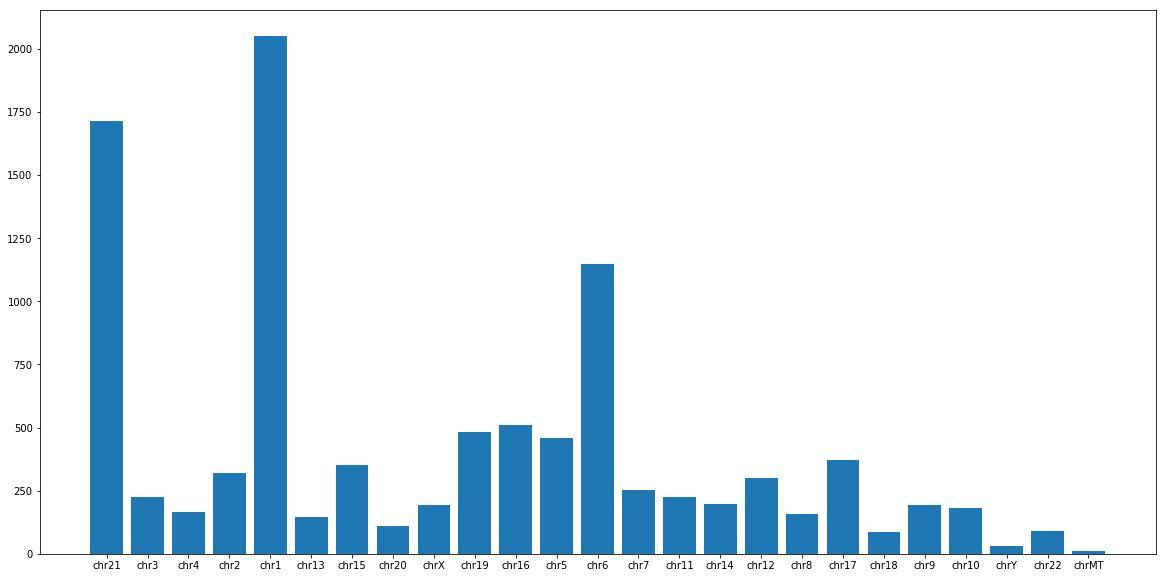

In [84]:
# create an object figure
plt.figure(figsize = (20, 10))
# draw the bar plot
plt.bar(x_scalar, chrom_alignments)
# assign labels to x-aixs
plt.xticks(x_scalar, chrom_names)
# show the plot here
plt.show()